In [1]:
# PASO 1: CARGA Y FILTRADO BIG DATA CON DASK

import dask.dataframe as dd
import pandas as pd

print("🚀 Iniciando motor de procesamiento paralelo Dask...")

# 1. Carga "Perezosa" (Lazy Evaluation)
# Dask NO satura la RAM. Lee el esquema del archivo gigante y crea un grafo de tareas.
# Usamos dtype=str para evitar que colapse adivinando tipos en millones de filas.
df_espana_dask = dd.read_csv('../data/raw/spanish_houses.csv', dtype=str)

# 2. Filtrado y Selección de Columnas en Paralelo
# Le decimos a Dask qué queremos, pero aún no realiza el cálculo.
df_sevilla_dask = df_espana_dask[df_espana_dask['loc_zone'].str.contains('sevilla', case=False, na=False)]

columnas_modelo = [
    'price', 'm2_real', 'room_num', 'bath_num', 'loc_city', 'loc_district',
    'house_type', 'balcony', 'garage', 'swimming_pool', 'terrace', 'storage_room', 
    'lift', 'garden', 'condition' 
]
df_modelo_dask = df_sevilla_dask[columnas_modelo]

# 3. EJECUCIÓN (The Compute Step)
# Ahora sí, Dask usa todos los núcleos de la CPU para buscar en el archivo gigante,
# extrae solo las casas de Sevilla y nos lo devuelve como un DataFrame de Pandas normal.
print("⏳ Filtrando el archivo masivo en múltiples núcleos (Out-of-core computation)...")
df_modelo = df_modelo_dask.compute(scheduler='threads')

# Volvemos a convertir el índice para que empiece en 0
df_modelo = df_modelo.reset_index(drop=True)

print(f"✅ ¡Éxito! Viviendas extraídas a la memoria local: {df_modelo.shape[0]}")
display(df_modelo.head())

🚀 Iniciando motor de procesamiento paralelo Dask...
⏳ Filtrando el archivo masivo en múltiples núcleos (Out-of-core computation)...
✅ ¡Éxito! Viviendas extraídas a la memoria local: 5076


,price,m2_real,room_num,bath_num,loc_city,loc_district,house_type,balcony,garage,swimming_pool,terrace,storage_room,lift,garden,condition
0,212000,302,5,3,Guillena,<NA>,Chalet pareado,0,plaza de garaje incluida en el precio,1,1,0,<NA>,1,<NA>
1,280000,500,5,3,Almadén de la Plata,"Calle las Granadinas, 20",Casa o chalet independiente,1,plaza de garaje incluida en el precio,1,1,1,<NA>,0,segunda mano/buen estado
2,50000,200,2,1,El Pedroso,"Calle Yesca, 7",Casa de pueblo,0,<NA>,0,0,0,<NA>,0,segunda mano/para reformar
3,90000,200,3,1,Guadalcanal,"Calle Vicente Amigo, 42",Casa de pueblo,1,plaza de garaje incluida en el precio,0,0,1,<NA>,0,segunda mano/buen estado
4,125000,120,4,3,Castilblanco de los Arroyos,"Calle Valdes Leal, 8",Piso,1,<NA>,0,1,0,0,0,segunda mano/buen estado


In [2]:

# PASO 2: LIMPIEZA Y PREPARACIÓN DE DATOS (VERSIÓN CORREGIDA)

df_modelo['room_num'] = df_modelo['room_num'].astype(str).replace('sin habitación', '0')
df_modelo['bath_num'] = df_modelo['bath_num'].astype(str).replace('sin baños', '0')

# 2. Forzamos el formato numérico 
columnas_numericas = ['price', 'm2_real', 'room_num', 'bath_num']
for col in columnas_numericas:
    # Primero limpiamos las comas en un texto temporal
    texto_limpio = df_modelo[col].astype(str).str.replace(',', '.')
    # Extraemos solo los números
    solo_numeros = texto_limpio.str.extract(r'(\d+\.?\d*)')[0]
    # Sobrescribimos la columna entera cambiándole el tipo de dato a numérico
    df_modelo[col] = pd.to_numeric(solo_numeros, errors='coerce')

# 3. Borramos los pisos que se han quedado sin Precio o Metros 
df_modelo = df_modelo.dropna(subset=['price', 'm2_real'])

# Mapeo (Creamos nueva variable operando elemento a elemento)
df_modelo['price_m2'] = df_modelo['price'] / df_modelo['m2_real']

# Ordenación (Organizamos del piso más caro al más barato)
df_modelo = df_modelo.sort_values(by='price', ascending=False)

print(f"Limpieza terminada. Nos quedan {df_modelo.shape[0]} casas en perfecto estado.")
print("Vistazo a las columnas numéricas clave:")
display(df_modelo[['price', 'm2_real', 'price_m2', 'room_num', 'bath_num']].head())

Limpieza terminada. Nos quedan 5076 casas en perfecto estado.
Vistazo a las columnas numéricas clave:


,price,m2_real,price_m2,room_num,bath_num
3796,6273680,10391,6.037609e+02,1,1
2798,6000000,19882,3.017805e+02,6,4
972,3834000,426000,9.000000e+00,8,6
2395,3200000,2000,1.600000e+03,4,4
1066,3000000,2,1.500000e+06,8,6


In [3]:

# PASO 3: ELIMINACIÓN DE OUTLIERS (VALORES ATÍPICOS)

print(f"Casas antes de limpiar rarezas: {df_modelo.shape[0]}")

# 1. Filtro de Precios: Casas entre 30.000€ y 2.000.000€
df_modelo = df_modelo[(df_modelo['price'] >= 30000) & (df_modelo['price'] <= 2000000)]

# 2. Filtro de Tamaño
# Nos quedamos con:
# - Casas normales (<= 800 m2) 
# - O mansiones reales (> 800 m2 Y que valgan al menos 1 millón)
df_modelo = df_modelo[(df_modelo['m2_real'] <= 800) | ((df_modelo['m2_real'] > 800) & (df_modelo['price'] >= 1000000))]

# 3. Filtro mínimo de m2 (por si hay errores de 0 m2 o 5 m2)
df_modelo = df_modelo[df_modelo['m2_real'] >= 25]

print(f"Casas después de limpiar rarezas: {df_modelo.shape[0]}")

# Volvemos a mirar los resultados
display(df_modelo[['price', 'm2_real', 'room_num', 'bath_num']].head())

Casas antes de limpiar rarezas: 5076
Casas después de limpiar rarezas: 4443


,price,m2_real,room_num,bath_num
1146,1950000,590000,12,11
893,1900000,450000,5,5
1378,1800000,1170,7,4
198,1700000,2700,8,6
2111,1700000,2220,8,10


In [4]:
# PASO 4: TRATAMIENTO DE NULOS Y VARIABLES BINARIAS

# Solo procesamos si la columna 'condition' existe todavía
if 'condition' in df_modelo.columns:
    # 1. Feature Engineering: Estado de la vivienda (USANDO TUS ETIQUETAS REALES)
    df_modelo['is_needs_renovating'] = df_modelo['condition'].str.contains('reformar', case=False, na=False).astype(int)
    df_modelo['is_new_development'] = df_modelo['condition'].str.contains('obra nueva', case=False, na=False).astype(int)
    
    # 2. Borramos 'condition' inmediatamente después de extraer la info
    df_modelo = df_modelo.drop(columns=['condition'])
    print("✅ Información de estado extraída y columna original borrada.")
else:
    print("⚠️ La columna 'condition' ya había sido procesada. Saltando paso...")

# 3. Variables de tipo "Extras"
columnas_extras = ['balcony', 'swimming_pool', 'terrace', 'storage_room', 'garden', 'lift']
for col in columnas_extras:
    df_modelo[col] = pd.to_numeric(df_modelo[col], errors='coerce').fillna(0).astype(int)

# 4. Garaje
df_modelo['garage'] = df_modelo['garage'].notna().astype(int)

# 5. Textos 
df_modelo['loc_district'] = df_modelo['loc_district'].fillna('Desconocido')
df_modelo['house_type'] = df_modelo['house_type'].fillna('Desconocido')

print("\n📊 ESTADO FINAL DE LA DETECCIÓN:")
print(f"Casas a reformar detectadas: {df_modelo['is_needs_renovating'].sum()}")
print(f"Casas obra nueva detectadas: {df_modelo['is_new_development'].sum()}")

✅ Información de estado extraída y columna original borrada.

📊 ESTADO FINAL DE LA DETECCIÓN:
Casas a reformar detectadas: 360
Casas obra nueva detectadas: 229


C:\Users\Sergio\AppData\Local\Temp\ipykernel_1544\4176714302.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_10_ciudades.index, y=top_10_ciudades.values, palette='magma', ax=axes[2])


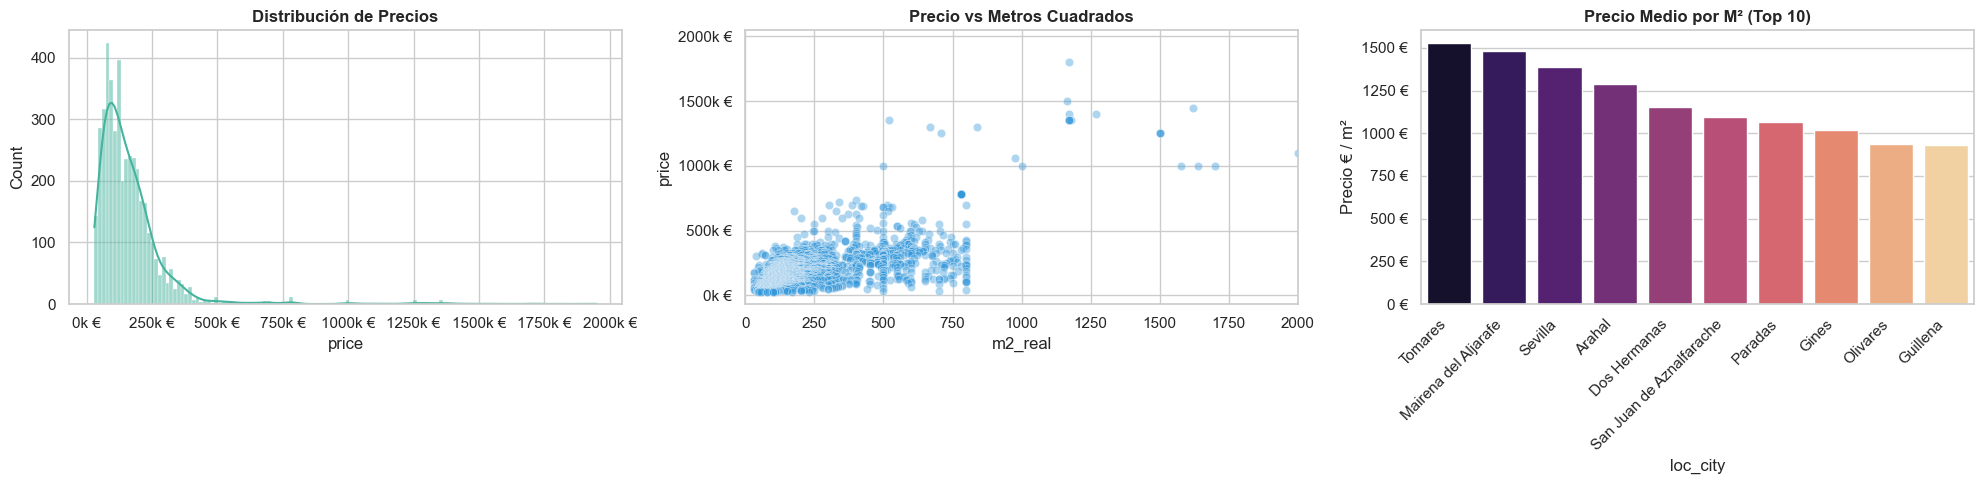

In [5]:
# PASO 5: VISUALIZACIÓN DE LOS DATOS LIMPIOS

import matplotlib.pyplot as plt
import seaborn as sns

# Configuramos el estilo 
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 3, figsize=(20, 5))

# 1. GRÁFICO IZQUIERDA: Distribución de Precios (Histograma)
sns.histplot(df_modelo['price'], kde=True, color='#45B39D', ax=axes[0])
axes[0].set_title('Distribución de Precios', fontweight='bold')
axes[0].set_xlabel('price')
axes[0].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{int(x/1000)}k €'))

# 2. GRÁFICO CENTRO: Precio vs Metros Cuadrados (Scatter Plot)
sns.scatterplot(data=df_modelo, x='m2_real', y='price', alpha=0.4, color='#3498DB', ax=axes[1])
axes[1].set_title('Precio vs Metros Cuadrados', fontweight='bold')
axes[1].set_xlim(0, 2000) 
axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{int(x/1000)}k €'))

# 3. GRÁFICO DERECHA: Precio Medio por M² (Bar Plot - Top 10)
top_10_ciudades = df_modelo.groupby('loc_city')['price_m2'].mean().sort_values(ascending=False).head(10)
sns.barplot(x=top_10_ciudades.index, y=top_10_ciudades.values, palette='magma', ax=axes[2])
axes[2].set_title('Precio Medio por M² (Top 10)', fontweight='bold')
axes[2].set_ylabel('Precio € / m²')
axes[2].set_xlabel('loc_city')
axes[2].set_xticks(range(len(top_10_ciudades)))
axes[2].set_xticklabels(top_10_ciudades.index, rotation=45, ha='right')
axes[2].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{int(x)} €'))

plt.tight_layout()
plt.show()

In [6]:
# PASO 6: GUARDADO DEL DATASET PROCESADO

# 1. Definimos la ruta y el nombre del archivo
ruta_final = '../data/processed/viviendas_sevilla_limpio.csv'

# 2. Guardamos el DataFrame sin el índice de filas
df_modelo.to_csv(ruta_final, index=False)

print(f"✅ ¡Éxito! El dataset ha sido blindado y guardado en: {ruta_final}")
print(f"📊 Resumen final: {df_modelo.shape[0]} filas y {df_modelo.shape[1]} columnas.")

# 3. Pequeño vistazo a los tipos de datos finales antes de la IA
print("\n--- TIPOS DE DATOS LISTOS PARA EL MODELO ---")
print(df_modelo.dtypes.value_counts())

✅ ¡Éxito! El dataset ha sido blindado y guardado en: ../data/processed/viviendas_sevilla_limpio.csv
📊 Resumen final: 4443 filas y 17 columnas.

--- TIPOS DE DATOS LISTOS PARA EL MODELO ---
int64      13
string      3
float64     1
Name: count, dtype: int64
